In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

In [34]:
class ConditionalAutoencoder(nn.Module):
    def __init__(self, input_dim, label_dim, latent_dim, output_dim):
        super(ConditionalAutoencoder, self).__init__()
        self.input_dim = input_dim
        self.label_dim = label_dim
        self.latent_dim = latent_dim
        self.output_dim = output_dim

        # Encoder
        # self.fc1 = nn.Linear(input_dim + label_dim, 512)
        # self.fc2 = nn.Linear(512, latent_dim)
        self.fc1 = nn.Linear(input_dim + label_dim, latent_dim)
        self.fc2 = nn.Linear(latent_dim, output_dim)

        # Decoder
        # self.fc3 = nn.Linear(latent_dim + label_dim, 512)
        # self.fc4 = nn.Linear(512, input_dim)
        self.fc3 = nn.Linear(output_dim + label_dim, latent_dim)
        self.fc4 = nn.Linear(latent_dim, input_dim)

    def encode(self, x, c):
        x = torch.cat([x, c], dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return x

    def decode(self, z, c):
        z = torch.cat([z, c], dim=1)
        z = F.relu(self.fc3(z))
        z = torch.sigmoid(self.fc4(z))
        return z

    def forward(self, x, c):
        z = self.encode(x, c)
        return self.decode(z, c)

In [35]:
# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [36]:
# Hyperparameters
input_dim = 784  # MNIST images are 28x28 pixels
label_dim = 10  # MNIST images have 10 labels
latent_dim = 128
output_dim = 64
learning_rate = 0.001
num_epochs = 40
batch_size = 64

In [37]:
# Load the MNIST dataset
# transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
# train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
train_data = MNIST(root="./data", train=True, transform=ToTensor(), download=True)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

In [38]:
# Initialize the model and optimizer
model = ConditionalAutoencoder(input_dim, label_dim, latent_dim, output_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Loss function
criterion = nn.MSELoss()

In [40]:
# Training loop
total_steps = len(train_loader)
for epoch in range(num_epochs):  # number of epochs
    for i, (data, labels) in enumerate(train_loader):
        # Flatten the data and one-hot encode the labels
        data = data.to(device)
        labels = labels.to(device)
        data = data.view(data.size(0), -1)
        labels = F.one_hot(labels, num_classes=label_dim)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        recon_data = model(data, labels.float())

        # Compute the loss
        loss = criterion(recon_data, data)

        # Backward pass
        loss.backward()

        # Update the weights
        optimizer.step()

        # if (i + 1) % 50 == 0:
        #     print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_steps}], Loss: {loss.item():.4f}")

    # Print the loss for this epoch
    print(f'Epoch {epoch+1}, Loss: {loss.item()}')



Epoch 1, Loss: 0.022146522998809814
Epoch 2, Loss: 0.013276233337819576
Epoch 3, Loss: 0.010930313728749752
Epoch 4, Loss: 0.009494324214756489
Epoch 5, Loss: 0.009524667635560036
Epoch 6, Loss: 0.0077986447140574455
Epoch 7, Loss: 0.007774943020194769
Epoch 8, Loss: 0.0069692679680883884
Epoch 9, Loss: 0.006789802573621273
Epoch 10, Loss: 0.005189160816371441
Epoch 11, Loss: 0.005693082697689533
Epoch 12, Loss: 0.006071389652788639
Epoch 13, Loss: 0.005236163269728422
Epoch 14, Loss: 0.005064602009952068
Epoch 15, Loss: 0.005857005249708891
Epoch 16, Loss: 0.004649720154702663
Epoch 17, Loss: 0.0059023224748671055
Epoch 18, Loss: 0.00488446606323123
Epoch 19, Loss: 0.004788999445736408
Epoch 20, Loss: 0.0042745191603899
Epoch 21, Loss: 0.004510078579187393
Epoch 22, Loss: 0.004901063162833452
Epoch 23, Loss: 0.004729180596768856
Epoch 24, Loss: 0.005250229965895414
Epoch 25, Loss: 0.004781961441040039
Epoch 26, Loss: 0.00430635828524828
Epoch 27, Loss: 0.00433749333024025
Epoch 28, Lo

In [41]:
# Now that the model is trained, we can use it to generate reconstructions
# for arbitrary labels. For example, let's generate reconstructions for
# the first 10 data points, but with the label for "5" for all of them.

# Get the first 10 data points and their labels
data, _ = next(iter(train_loader))
data = data[:10].view(-1, 784)  # Reshape the data to have shape (10, 784)

# Apply the same transformation as during training
data = (data - 0.5) / 0.5

# Create labels for "5"
labels = torch.zeros(10, 10)
labels[:, 5] = 1

# Generate reconstructions
with torch.no_grad():
    recon_data = model(data.to(device), labels.to(device).float())
# The variable `recon_data` now contains the reconstructions of the first
# 10 data points as if they all had the label "5".

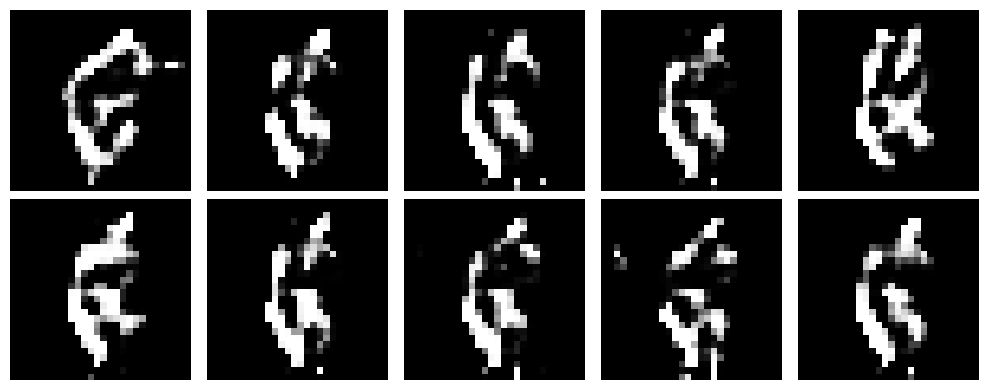

In [42]:
import matplotlib.pyplot as plt

# Reshape the reconstructions to have shape (28, 28)
recon_data = recon_data.cpu().view(-1, 28, 28).detach().numpy()

# Plot the reconstructions
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(recon_data[i], cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()
